In [1]:
import pandas as pd
import numpy as np

# تحميل ملف البيانات الأصلي دون أي تعديل أو تنظيف
df = pd.read_csv('../data/jm1.csv')

In [2]:
def show_general_summary(dataframe):
    print("==================================================")
    print("📋 الملخص العام لمجموعة البيانات (NASA MDP JM1(Software Defect Prediction))")
    print("==================================================")
    print(f"🔹 عدد الصفوف (العينات): {dataframe.shape[0]:,} سطر برميجي")
    print(f"🔹 عدد الأعمدة (الميزات): {dataframe.shape[1]} عموداً")
    print("==================================================")

# تشغيل الدالة
show_general_summary(df)

📋 الملخص العام لمجموعة البيانات (NASA MDP JM1(Software Defect Prediction))
🔹 عدد الصفوف (العينات): 10,885 سطر برميجي
🔹 عدد الأعمدة (الميزات): 22 عموداً


In [3]:
def check_class_distribution(dataframe):
    print("==================================================")
    print("📊 توزيع فئات عمود الهدف والتصنيف (defects)")
    print("==================================================")
    
    # حساب التكرار والنسبة المئوية لـ true و false
    counts = dataframe['defects'].value_counts()
    percentages = dataframe['defects'].value_counts(normalize=True) * 100
    
    for val in counts.index:
        print(f"🔹 الفئة [{val}]: العدد = {counts[val]:,} دالة | النسبة = {percentages[val]:.2f}%")
    print("==================================================")

# تشغيل الدالة
check_class_distribution(df)

📊 توزيع فئات عمود الهدف والتصنيف (defects)
🔹 الفئة [False]: العدد = 8,779 دالة | النسبة = 80.65%
🔹 الفئة [True]: العدد = 2,106 دالة | النسبة = 19.35%


In [4]:
def show_technical_structure():
    print("==================================================")
    print("🛠️ الهيكل التقني لتصنيف الأعمدة الـ 22")
    print("==================================================")
    structure = {
        "مقاييس أسطر الكود (Lines of code)": "5 أعمدة (loc, lOCode, lOComment, lOBlank, lOCodeAndComment)",
        "مقاييس التعقيد الدوري لـ McCabe": "3 أعمدة (v(g), ev(g), iv(g))",
        "مقاييس أساسية لـ Halstead": "4 أعمدة (uniq_Op, uniq_Opnd, total_Op, total_Opnd)",
        "مقاييس مشتقة لـ Halstead": "8 أعمدة (n, v, l, d, i, e, b, t)",
        "حساب التفرعات البرمجية": "عمود واحد (branchCount)",
        "عمود الهدف والتصنيف النهائي": "عمود واحد (defects)"
    }
    for group, desc in structure.items():
        print(f"📌 {group} ➔ {desc}")
    print("==================================================")

# تشغيل الدالة
show_technical_structure()

🛠️ الهيكل التقني لتصنيف الأعمدة الـ 22
📌 مقاييس أسطر الكود (Lines of code) ➔ 5 أعمدة (loc, lOCode, lOComment, lOBlank, lOCodeAndComment)
📌 مقاييس التعقيد الدوري لـ McCabe ➔ 3 أعمدة (v(g), ev(g), iv(g))
📌 مقاييس أساسية لـ Halstead ➔ 4 أعمدة (uniq_Op, uniq_Opnd, total_Op, total_Opnd)
📌 مقاييس مشتقة لـ Halstead ➔ 8 أعمدة (n, v, l, d, i, e, b, t)
📌 حساب التفرعات البرمجية ➔ عمود واحد (branchCount)
📌 عمود الهدف والتصنيف النهائي ➔ عمود واحد (defects)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            10885 non-null

In [6]:
def check_hidden_missing_values(dataframe):
    print("==================================================")
    print("🔍 إحصائيات القيم المفقودة على شكل علامة استفهام (?)")
    print("==================================================")
    
    # حساب عدد علامات الاستفهام في كل عمود
    question_marks_counts = (dataframe == '?').sum()
    total_missing = question_marks_counts.sum()
    
    if total_missing > 0:
        print(f"⚠️ تم العثور على إجمالي ({total_missing}) قيمة مفقودة على شكل '?'")
        print("\n📌 تفاصيل الأعمدة التي تحتوي على هذه العلامة وعَدَدُها:")
        for col, count in question_marks_counts.items():
            if count > 0:
                print(f"   - العمود [{col}]: يحتوي على {count} قيم مفقودة")
    else:
        print("✅ لا توجد علامات استفهام '?' ظاهرية في خلايا الملف الحالي.")
    print("==================================================")

# 1. تشغيل دالة الإحصائيات العامة أولاً
check_hidden_missing_values(df)

# 2. استخراج وعرض عينة حية لإثبات المشكلة للدكتور في نفس الخلية
target_columns = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']
proven_rows = df[df[target_columns].isin(['?']).any(axis=1)]

if len(proven_rows) > 0:
    print("\n==================================================")
    print("📊 تقرير الإثبات للدكتور: تحديد موقع وعينة من علامات (?)")
    print("==================================================")
    print(f"🔹 إجمالي الصفوف المتأثرة بالمشكلة: {len(proven_rows)} صفاً")
    print("🔹 أرقام بعض هذه الصفوف (Index) في الملف: ", list(proven_rows.index[:5]))
    print("==================================================")
    
    # استخدام display هنا يضمن ظهور الجدول كـ HTML منسق تحت النصوص مباشرة
    display(proven_rows[target_columns].head())

🔍 إحصائيات القيم المفقودة على شكل علامة استفهام (?)
⚠️ تم العثور على إجمالي (25) قيمة مفقودة على شكل '?'

📌 تفاصيل الأعمدة التي تحتوي على هذه العلامة وعَدَدُها:
   - العمود [uniq_Op]: يحتوي على 5 قيم مفقودة
   - العمود [uniq_Opnd]: يحتوي على 5 قيم مفقودة
   - العمود [total_Op]: يحتوي على 5 قيم مفقودة
   - العمود [total_Opnd]: يحتوي على 5 قيم مفقودة
   - العمود [branchCount]: يحتوي على 5 قيم مفقودة

📊 تقرير الإثبات للدكتور: تحديد موقع وعينة من علامات (?)
🔹 إجمالي الصفوف المتأثرة بالمشكلة: 5 صفاً
🔹 أرقام بعض هذه الصفوف (Index) في الملف:  [143, 358, 1598, 4214, 8279]


,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
143,?,?,?,?,?
358,?,?,?,?,?
1598,?,?,?,?,?
4214,?,?,?,?,?
8279,?,?,?,?,?


In [7]:
# 3. عرض وصف إحصائي للبيانات بعد التحقق من القيم المفقودة وقبل أي تنظيف أو معالجة
df.describe()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment
count,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,1.088500e+04,10885.000000,10885.000000,10885.00000,10885.000000
mean,42.016178,6.348590,3.401047,4.001599,114.389738,673.758017,0.135335,14.177237,29.439544,3.683637e+04,0.224766,2.046465e+03,26.252274,2.737529,4.62554,0.370785
std,76.593332,13.019695,6.771869,9.116889,249.502091,1938.856196,0.160538,18.709900,34.418313,4.343678e+05,0.646408,2.413154e+04,59.611201,9.008608,9.96813,1.907969
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.860000,1.619400e+02,0.020000,9.000000e+00,4.000000,0.000000,0.00000,0.000000
50%,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.930000,2.031020e+03,0.070000,1.128300e+02,13.000000,0.000000,2.00000,0.000000
75%,46.000000,7.000000,3.000000,4.000000,119.000000,621.480000,0.160000,18.900000,36.780000,1.141643e+04,0.210000,6.342500e+02,28.000000,2.000000,5.00000,0.000000
max,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.780000,3.107978e+07,26.950000,1.726655e+06,2824.000000,344.000000,447.00000,108.000000


In [8]:
# إنشاء نسخة جديدة من DataFrame الأصلي لتجنب التعديل المباشر عليه
df_cleaned = df.copy()

# استبدال جميع علامات الاستفهام '?' بـ np.nan ليتعرف عليها باندا كقيم مفقودة
df_cleaned = df_cleaned.replace('?', np.nan)

# حذف جميع الصفوف التي تحتوي على أي قيمة مفقودة (NaN)
df_cleaned = df_cleaned.dropna()

# تحديد الأعمدة الخمسة التي كانت تحتوي على نصوص وتحتاج تحويل إلى قيم رقمية
target_columns = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']

# المرور على كل عمود وتحويل نوع بياناته من نص إلى أرقام
for col in target_columns:
    # تحويل بيانات العمود إلى أرقام شجرية/عشرية float
    df_cleaned[col] = pd.to_numeric(df_cleaned[col])

# تحويل عمود الهدف defects من قيم منطقية True/False إلى أرقام 1/0
df_cleaned['defects'] = df_cleaned['defects'].astype(int)

# طباعة حجم البيانات قبل وبعد الحذف للتأكد
print(f"حجم البيانات الخام: {df.shape[0]} صفاً")
print(f"حجم البيانات بعد حذف القيم المفقودة: {df_cleaned.shape[0]} صفاً")

حجم البيانات الخام: 10885 صفاً
حجم البيانات بعد حذف القيم المفقودة: 10880 صفاً


In [9]:
# عرض هيكل البيانات الجديد للتأكد من اختفاء النصوص والـ NaN
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 10880 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10880 non-null  float64
 1   v(g)               10880 non-null  float64
 2   ev(g)              10880 non-null  float64
 3   iv(g)              10880 non-null  float64
 4   n                  10880 non-null  float64
 5   v                  10880 non-null  float64
 6   l                  10880 non-null  float64
 7   d                  10880 non-null  float64
 8   i                  10880 non-null  float64
 9   e                  10880 non-null  float64
 10  b                  10880 non-null  float64
 11  t                  10880 non-null  float64
 12  lOCode             10880 non-null  int64  
 13  lOComment          10880 non-null  int64  
 14  lOBlank            10880 non-null  int64  
 15  locCodeAndComment  10880 non-null  int64  
 16  uniq_Op            10880 non-null  flo

In [10]:
df_cleaned.describe()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
count,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.00000,1.088000e+04,...,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000,10880.000000
mean,42.020138,6.347739,3.400037,4.001415,114.391388,673.772003,0.135352,14.177339,29.43885,3.684563e+04,...,26.253125,2.738787,4.625092,0.370956,11.177592,16.751857,68.110588,46.388989,11.292316,0.193290
std,76.608641,13.021924,6.772697,9.118682,249.549291,1939.253379,0.160552,18.712325,34.42332,4.344671e+05,...,59.622819,9.010486,9.969914,1.908391,10.045255,26.667883,151.513836,100.351845,22.597617,0.394897
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.86000,1.619400e+02,...,4.000000,0.000000,0.000000,0.000000,5.000000,4.000000,8.000000,6.000000,3.000000,0.000000
50%,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.92500,2.031020e+03,...,13.000000,0.000000,2.000000,0.000000,11.000000,11.000000,29.000000,19.000000,5.000000,0.000000
75%,46.000000,7.000000,3.000000,4.000000,119.000000,620.850000,0.160000,18.902500,36.78000,1.141615e+04,...,28.000000,2.000000,5.000000,0.000000,16.000000,21.000000,71.000000,48.000000,13.000000,0.000000
max,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.78000,3.107978e+07,...,2824.000000,344.000000,447.000000,108.000000,411.000000,1026.000000,5420.000000,3021.000000,826.000000,1.000000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19344\3422590425.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='defects', data=df_cleaned, palette='Set2')


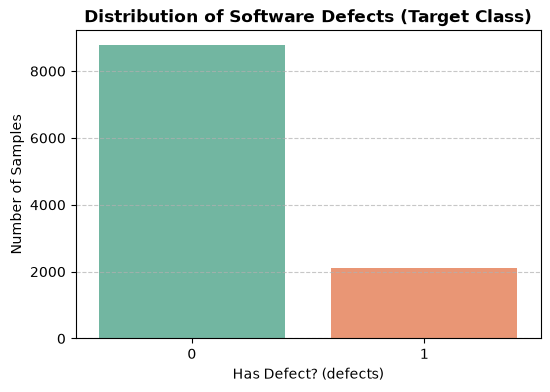

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# اسم مجلد الريبورت الموجود داخل مشروعك
folder_name = os.path.join('..', 'reports')

plt.figure(figsize=(6, 4))
sns.countplot(x='defects', data=df_cleaned, palette='Set2')

plt.title('Distribution of Software Defects (Target Class)', fontsize=12, fontweight='bold')
plt.xlabel('Has Defect? (defects)', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 💾 حفظ الصورة بدقة عالية داخل المجلد قبل العرض
plt.savefig(os.path.join(folder_name, 'defects_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19344\1960044627.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='defects', y='loc', data=df_cleaned, palette='Pastel1')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19344\1960044627.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='defects', y='v(g)', data=df_cleaned, palette='Pastel2')


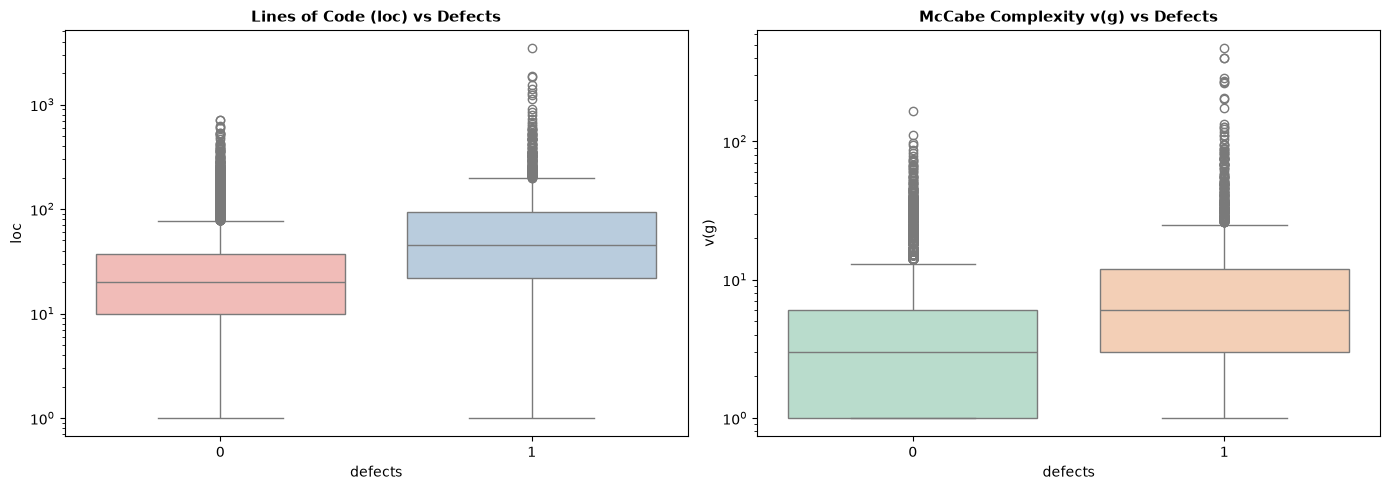

In [12]:
folder_name = os.path.join('..', 'reports')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# المخطط الأول
sns.boxplot(ax=axes[0], x='defects', y='loc', data=df_cleaned, palette='Pastel1')
axes[0].set_title('Lines of Code (loc) vs Defects', fontsize=11, fontweight='bold')
axes[0].set_yscale('log')

# المخطط الثاني
sns.boxplot(ax=axes[1], x='defects', y='v(g)', data=df_cleaned, palette='Pastel2')
axes[1].set_title('McCabe Complexity v(g) vs Defects', fontsize=11, fontweight='bold')
axes[1].set_yscale('log')

plt.tight_layout()

# 💾 حفظ الصورة بدقة عالية داخل المجلد قبل العرض
plt.savefig(os.path.join(folder_name, 'metrics_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()

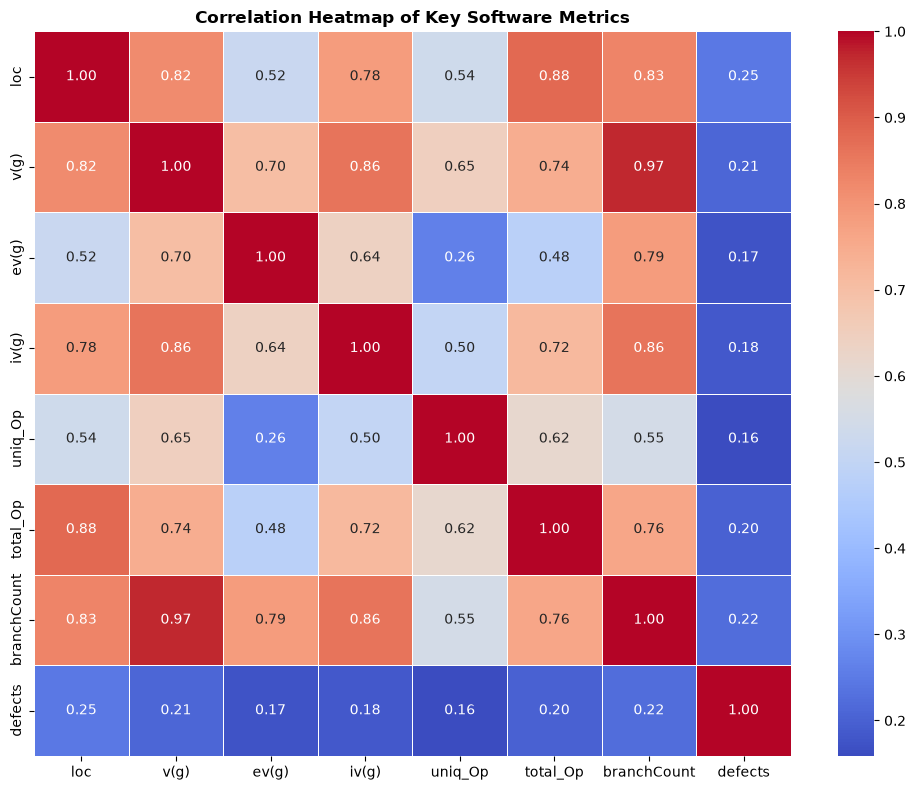

In [13]:
folder_name = os.path.join('..', 'reports')

selected_features = ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'uniq_Op', 'total_Op', 'branchCount', 'defects']

plt.figure(figsize=(10, 8))
correlation_matrix = df_cleaned[selected_features].astype(float).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Correlation Heatmap of Key Software Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()

# 💾 حفظ الصورة بدقة عالية داخل المجلد قبل العرض
plt.savefig(os.path.join(folder_name, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

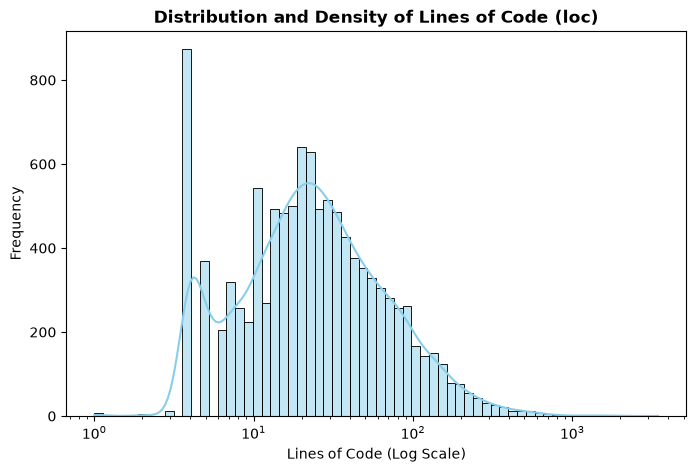

In [14]:
folder_name = os.path.join('..', 'reports')

plt.figure(figsize=(8, 5))
# رسم التوزيع مع خط الكثافة KDE واستخدام مقياس لوغاريتمي بسبب تفاوت القيم
sns.histplot(data=df_cleaned, x='loc', kde=True, color='skyblue', log_scale=True)

plt.title('Distribution and Density of Lines of Code (loc)', fontsize=12, fontweight='bold')
plt.xlabel('Lines of Code (Log Scale)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

# 💾 حفظ الصورة
plt.savefig(os.path.join(folder_name, 'loc_distribution_histogram.png'), dpi=300, bbox_inches='tight')
plt.show()

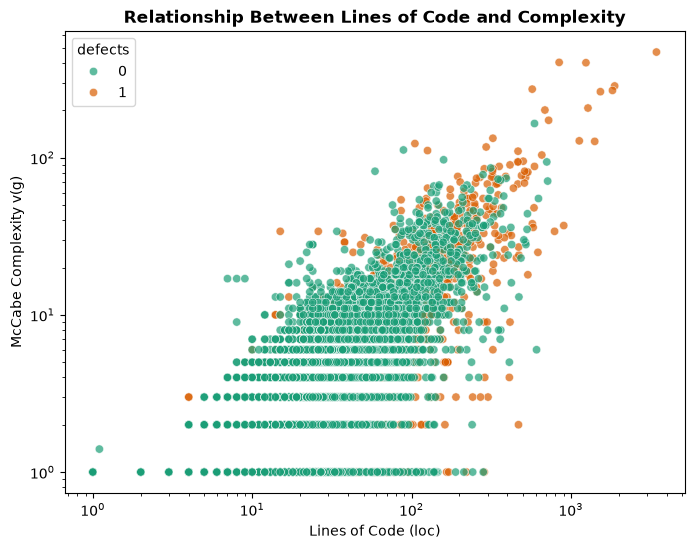

In [15]:
folder_name = os.path.join('..', 'reports')

plt.figure(figsize=(8, 6))
# رسم نقاط التشتت
sns.scatterplot(data=df_cleaned, x='loc', y='v(g)', hue='defects', palette='Dark2', alpha=0.7)

plt.title('Relationship Between Lines of Code and Complexity', fontsize=12, fontweight='bold')
plt.xlabel('Lines of Code (loc)', fontsize=10)
plt.ylabel('McCabe Complexity v(g)', fontsize=10)
plt.xscale('log')
plt.yscale('log')

# 💾 حفظ الصورة
plt.savefig(os.path.join(folder_name, 'loc_vs_complexity_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19344\3741799745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_cleaned, x='defects', y='uniq_Op', palette='Set3')


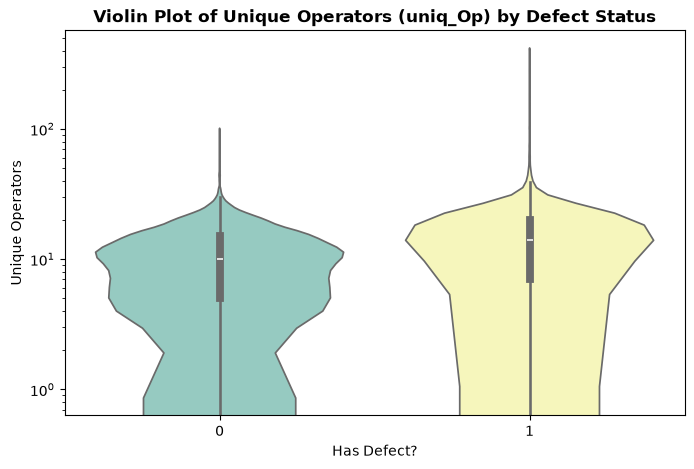

In [16]:
folder_name = os.path.join('..', 'reports')

plt.figure(figsize=(8, 5))
# رسم مخطط الكمان
sns.violinplot(data=df_cleaned, x='defects', y='uniq_Op', palette='Set3')

plt.title('Violin Plot of Unique Operators (uniq_Op) by Defect Status', fontsize=12, fontweight='bold')
plt.xlabel('Has Defect?', fontsize=10)
plt.ylabel('Unique Operators', fontsize=10)
plt.yscale('log')

# 💾 حفظ الصورة
plt.savefig(os.path.join(folder_name, 'uniq_operators_violin.png'), dpi=300, bbox_inches='tight')
plt.show()

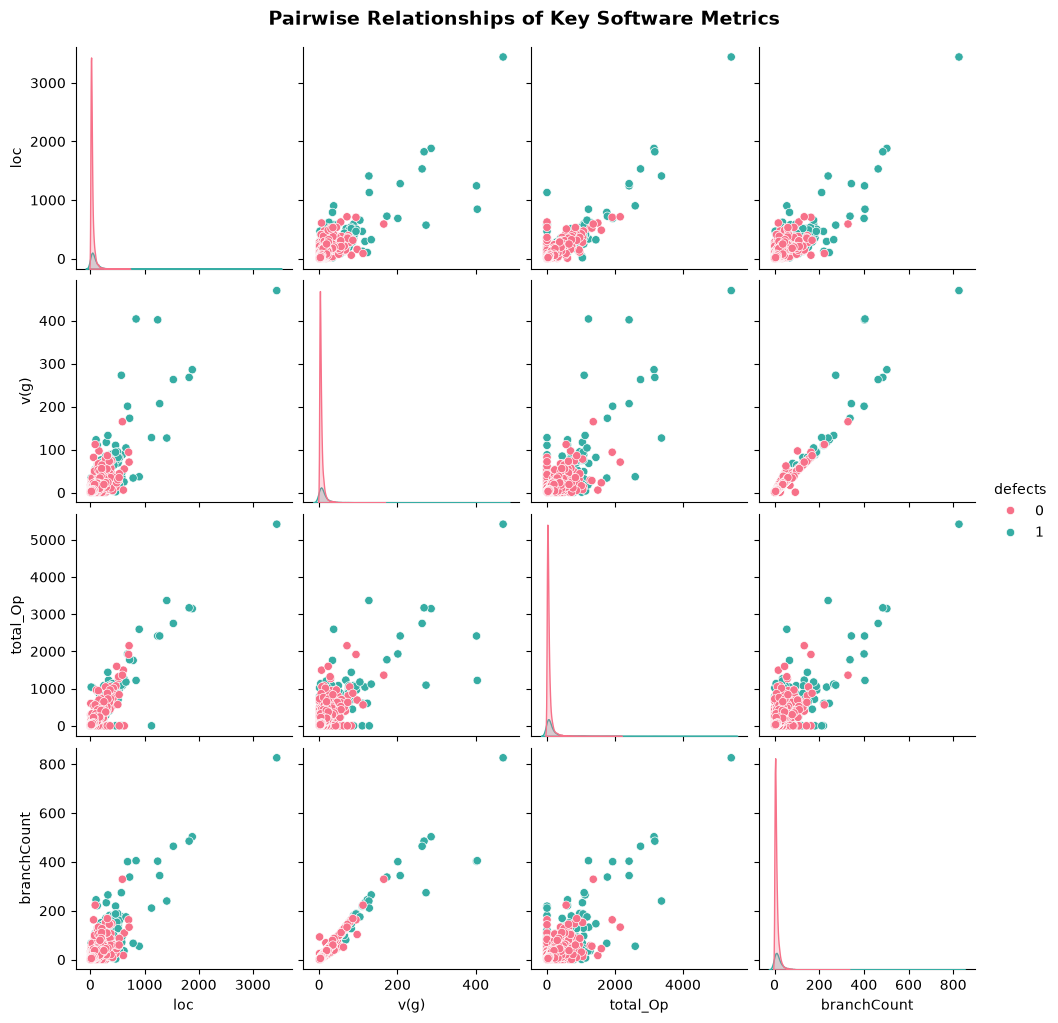

In [17]:
folder_name = os.path.join('..', 'reports')

# اختيار 4 ميزات ممثلة بالإضافة لعمود الهدف
features_to_plot = ['loc', 'v(g)', 'total_Op', 'branchCount', 'defects']

# رسم مخطط العلاقات الثنائية (يأخذ بضع ثوانٍ للتشغيل)
g = sns.pairplot(df_cleaned[features_to_plot], hue='defects', palette='husl', diag_kind='kde')
g.fig.suptitle('Pairwise Relationships of Key Software Metrics', y=1.02, fontsize=14, fontweight='bold')

# 💾 حفظ الصورة الشاملة
g.savefig(os.path.join(folder_name, 'comprehensive_pairplot.png'), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# استيراد دالة تقسيم البيانات من مكتبة scikit-learn
from sklearn.model_selection import train_test_split

# فصل الميزات (X) بحذف عمود الهدف defects
X = df_cleaned.drop(columns=['defects'])

# تحديد متغير الهدف (y) وهو عمود defects
y = df_cleaned['defects']

# تقسيم البيانات إلى 80% للتدريب و 20% للاختبار مع الحفاظ على نسبة التوزيع stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

# طباعة حجم مجموعة التدريب
print(f"حجم مجموعة التدريب: {X_train.shape[0]} عينة")

# طباعة حجم مجموعة الاختبار
print(f"حجم مجموعة الاختبار: {X_test.shape[0]} عينة")

حجم مجموعة التدريب: 8704 عينة
حجم مجموعة الاختبار: 2176 عينة


In [19]:
# استيراد نموذج الانحدار اللوجستي
from sklearn.linear_model import LogisticRegression

# استيراد نموذج أشجار القرار
from sklearn.tree import DecisionTreeClassifier

# استيراد نموذج الغابة العشوائية
from sklearn.ensemble import RandomForestClassifier

# استيراد نموذج التدرج الشجري Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# استيراد أدوات قياس الدقة والأداء
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# تعريف النماذج المراد تدريبها واختبارها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# قائمة لتخزين النتائج التقييمية لكل نموذج
results_list = []

# حلقة تكرارية لتدريب وتقييم كل نموذج
for name, model in models.items():
    # تدريب النموذج على بيانات التدريب
    model.fit(X_train, y_train)
    
    # التنبؤ بالفئات على بيانات الاختبار
    y_pred = model.predict(X_test)
    
    # التنبؤ بالاحتمالات لحساب ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # حساب المقاييس
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # إضافة النتائج القاموسية إلى القائمة
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# تحويل القائمة إلى DataFrame لمقارنة الأداء
comparison_df = pd.DataFrame(results_list)

# ترتيب الجدول تنازلياً بحسب مقياس F1-Score
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# عرض جدول المقارنة النهائي
display(comparison_df)

d:\AI_Code_Reviewer\my_venv_ACR\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.755055,0.369159,0.375297,0.372203,0.590590
1,Random Forest,0.806985,0.502890,0.206651,0.292929,0.740449
2,Gradient Boosting,0.802390,0.456311,0.111639,0.179389,0.738271
3,Logistic Regression,0.799173,0.423077,0.104513,0.167619,0.567705


In [20]:
from sklearn.preprocessing import (
    StandardScaler,
)  # استيراد أداة توحيد مقاييس البيانات لمنع تحذير عدم تقارب اللوجستي
from sklearn.utils.class_weight import (
    compute_sample_weight,
)  # استيراد دالة أوزان العينات لموازنة الجراديانت بوستينج

# 1. تطبيق التقييس (Scaling) للبيانات لتخليص الانحدار اللوجستي من تحذير عدم التقارب كلياً
scaler = StandardScaler()  # إنشاء كائن أداة التقييس القياسي
X_train_scaled = (
    scaler.fit_transform(X_train)
)  # توحيد مقاييس بيانات التدريب وحساب المتوسط والانحراف
X_test_scaled = scaler.transform(
    X_test
)  # تطبيق نفس مقاييس التقييس على بيانات الاختبار

# 2. تعريف الخوارزميات الأربع مع الموازنة
models = {  # إنشاء قاموس النماذج المراد مقارتها
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42
    ),  # الانحدار اللوجستي الموازن
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),  # شجرة القرار الموازنة
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42
    ),  # الغابة العشوائية الموازنة
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),  # الجراديانت بوستينج
}  # إغلاق قاموس النماذج

# 3. حساب أوزان العينات الموازنة للجراديانت بوستينج
sample_weights_gb = compute_sample_weight(
    'balanced', y_train
)  # حساب وزن كل عينة في y_train

results = []  # قائمة فارغة لتجميع النتائج الحسابية

# 4. التكرار والتدريب بالبيانات المقيسة
for name, model in models.items():  # حلقة تكرارية تمر على اسم الخوارزمية وكائنها
    if name == 'Gradient Boosting':  # شرط في حال كان النموذج هو الجراديانت بوستينج
        model.fit(
            X_train_scaled, y_train, sample_weight=sample_weights_gb
        )  # تدريب الجراديانت بوستينج بالبيانات المقيسة وأوزان العينات
    else:  # لبقية النماذج الثلاثة
        model.fit(
            X_train_scaled, y_train
        )  # التدريب المباشر باستخدام البيانات المقيسة

    # التنبؤ بالفئات والاحتمالات باستخدام بيانات الاختبار المقيسة
    y_pred = model.predict(
        X_test_scaled
    )  # التنبؤ بالفئات المباشرة على بيانات الاختبار المقيسة
    y_proba = model.predict_proba(X_test_scaled)[
        :, 1
    ]  # التنبؤ بالاحتمالات لحساب ROC-AUC

    # حساب كافة دوال التقييم
    acc = accuracy_score(y_test, y_pred)  # حساب الدقة الإجمالية Accuracy
    f1 = f1_score(y_test, y_pred)  # حساب F1-Score
    recall = recall_score(y_test, y_pred)  # حساب الاستدعاء Recall
    precision = precision_score(y_test, y_pred)  # حساب Precision
    auc = roc_auc_score(
        y_test, y_proba
    )  # حساب المساحة تحت منحنى ROC لمعرفة قدرة الفصل

    # تجميع النتائج
    results.append({  # إضافة قاموس التقييم إلى قائمة النتائج
        'Algorithm': name,  # تخزين اسم الخوارزمية
        'Accuracy': acc,  # تخزين قيمة Accuracy
        'F1_Score': f1,  # تخزين قيمة F1-Score
        'Recall': recall,  # تخزين قيمة Recall
        'Precision': precision,  # تخزين قيمة Precision
        'ROC_AUC': auc,  # تخزين قيمة ROC_AUC
    })  # إغلاق القاموس للنموذج الحالي

# 5. عرض النتائج النهائية مرتبة تلقائياً
df_results = (
    pd.DataFrame(results)
)  # تحويل قائمة النتائج إلى جدول Pandas DataFrame
df_results = df_results.sort_values(
    by=['F1_Score', 'Accuracy'], ascending=[False, False]
)  # ترتيب الجدول تنازلياً بحسب F1-Score ثم Accuracy

print('=== النتائج النهائية بعد التقييس والموازنة ===')  # طباعة عنوان الجدول
print(
    df_results.to_string(index=False)
)  # عرض الجدول المكتمل بدون أرقام الصفوف

=== النتائج النهائية بعد التقييس والموازنة ===
          Algorithm  Accuracy  F1_Score   Recall  Precision  ROC_AUC
  Gradient Boosting  0.698070  0.457473 0.657957   0.350633 0.738307
Logistic Regression  0.708640  0.444834 0.603325   0.352288 0.708481
      Random Forest  0.770680  0.410862 0.413302   0.408451 0.729931
      Decision Tree  0.741728  0.367117 0.387173   0.349036 0.591191


In [21]:
from sklearn.model_selection import (
    GridSearchCV,
)  # استيراد أداة البحث الشامل عن أفضل المعاملات

# 1. تقييس البيانات لتجهيزها للتدريب والبحث الشامل
scaler = StandardScaler()  # إنشاء كائن توحيد المقاييس (StandardScaler)
X_train_scaled = (
    scaler.fit_transform(X_train)
)  # توحيد مقاييس بيانات التدريب وحساب المتوسط والانحراف المعياري
X_test_scaled = scaler.transform(
    X_test
)  # تطبيق نفس التقييس على بيانات الاختبار لضمان عدم تسريب البيانات

# 2. تحديد شبكة المعاملات المراد تجريبها لخوارزمية Random Forest
rf_param_grid = {  # قاموس يضم المعاملات المراد البحث عن الأفضل من بينها
    'n_estimators': [100, 200],  # تجربة عدد الأشجار في الغابة (100 و 200)
    'max_depth': [5, 10, 15],  # تجربة أقصى عمق مسموح به للشجرة
    'min_samples_split': [
        2,
        5,
    ],  # تجربة الحد الأدنى للعينات المطلوب لتقسيم العقدة
}  # إغلاق قاموس معاملات الغابة العشوائية

# 3. تحديد شبكة المعاملات لخوارزمية Gradient Boosting
gb_param_grid = {  # قاموس يضم المعاملات المراد البحث عن الأفضل من بينها
    'n_estimators': [100, 200],  # تجربة عدد الأشجار التتبعية (100 و 200)
    'learning_rate': [0.01, 0.1],  # تجربة معدل التعلم لتحديد تأثير كل شجرة
    'max_depth': [3, 5],  # تجربة العمق الأقصى للأشجار التتبعية
}  # إغلاق قاموس معاملات الجراديانت بوستينج

# 4. البحث عن أفضل معاملات لـ Random Forest وتسريع العملية عبر n_jobs=-1
rf_grid = GridSearchCV(  # إنشاء كائن البحث الشامل لخوارزمية الغابة العشوائية
    estimator=RandomForestClassifier(
        class_weight='balanced', random_state=42
    ),  # تحديد النموذج الأساسي مع موازنة الفئات
    param_grid=rf_param_grid,  # تمرير شبكة المعاملات المراد تجريبها
    scoring='f1',  # الاعتماد على F1-Score كمعيار أساسي لاختيار النموذج الأفضل
    cv=5,  # استخدام التحقق التقاطعي (Cross-Validation) لخمس مرات
    n_jobs=-1,  # استغلال جميع أنوية المعالج (CPU) بالتوازي لتسريع العملية بشكل ملحوظ
)  # إغلاق كائن البحث الشامل للغابة العشوائية
rf_grid.fit(
    X_train_scaled, y_train
)  # بدء عملية البحث والتدريب على بيانات التدريب المقيسة
best_rf = (
    rf_grid.best_estimator_
)  # استخراج أفضل نموذج للغابة العشوائية بعد الوصول لأفضل المعاملات

# 5. البحث عن أفضل معاملات لـ Gradient Boosting وتسريع العملية عبر n_jobs=-1
sample_weights_gb = compute_sample_weight(
    'balanced', y_train
)  # حساب أوزان العينات الموازنة خصيصاً للجراديانت بوستينج
gb_grid = GridSearchCV(  # إنشاء كائن البحث الشامل لخوارزمية الجراديانت بوستينج
    estimator=GradientBoostingClassifier(
        random_state=42
    ),  # تحديد النموذج الأساسي
    param_grid=gb_param_grid,  # تمرير شبكة المعاملات
    scoring='f1',  # التقييم بناءً على F1-Score
    cv=5,  # استخدام التحقق التقاطعي لخمس مرات
    n_jobs=-1,  # استغلال كافة أنوية المعالج بالتوازي للسرعة الفائقة
)  # إغلاق كائن البحث الشامل للجراديانت بوستينج
gb_grid.fit(  # بدء عملية البحث والتدريب للجراديانت بوستينج
    X_train_scaled, y_train, sample_weight=sample_weights_gb
)  # تمرير أوزان العينات الموازنة أثناء عملية التدريب
best_gb = (
    gb_grid.best_estimator_
)  # استخراج أفضل نموذج للجراديانت بوستينج بعد ضبط المعاملات

# 6. تقييم النموذجين المحسّنين على بيانات الاختبار
tuned_models = {  # قاموس يجمع النموذجين بعد الوصول للأداء الأفضل
    'Random Forest (Tuned)': best_rf,  # نموذج الغابة العشوائية المحسن
    'Gradient Boosting (Tuned)': best_gb,  # نموذج الجراديانت بوستينج المحسن
}  # إغلاق قاموس النماذج المحسنة

tuned_results = []  # مصفوفة لتجميع نتائج مقاييس التقييم
for (
    name,
    model,
) in tuned_models.items():  # حلقة تكرارية تمر على اسم النموذج وكائنه
    y_pred = model.predict(
        X_test_scaled
    )  # التنبؤ بالفئات على بيانات الاختبار المقيسة
    acc = accuracy_score(
        y_test, y_pred
    )  # حساب الدقة الإجمالية (Accuracy)
    f1 = f1_score(
        y_test, y_pred
    )  # حساب قيمة F1-Score الموازنة بين الدقة والاستدعاء
    rec = recall_score(
        y_test, y_pred
    )  # حساب الاستدعاء (Recall) لكشف الحالات الإيجابية
    prec = precision_score(
        y_test, y_pred
    )  # تصحيح الخطأ الإملائي وحساب الدقة التنبؤية (Precision)

    tuned_results.append({  # إلحاق نتائج التقييم الحالية بالقائمة
        'Algorithm': name,  # تخزين اسم الخوارزمية
        'Accuracy': acc,  # تخزين قيمة Accuracy
        'F1_Score': f1,  # تخزين قيمة F1-Score
        'Recall': rec,  # تخزين قيمة Recall
        'Precision': prec,  # تخزين قيمة Precision
    })  # إغلاق قاموس النتائج

# 7. عرض جدول المقارنة النهائي بعد التحسين والضبط
df_tuned = pd.DataFrame(tuned_results)  # تحويل النتائج إلى جدول Pandas DataFrame
print('=== نتائج النماذج بعد ضبط المعاملات وتحسين الأداء ===')  # طباعة عنوان النتائج
print(
    df_tuned.to_string(index=False)
)  # عرض الجدول كاملاً بصورة واضحة وبدون أرقام الصفوف

=== نتائج النماذج بعد ضبط المعاملات وتحسين الأداء ===
                Algorithm  Accuracy  F1_Score   Recall  Precision
    Random Forest (Tuned)  0.748162  0.446465 0.524941   0.388401
Gradient Boosting (Tuned)  0.698070  0.457473 0.657957   0.350633



==================== تقرير التقييم التفصيلي لـ [Random Forest (Tuned)] ====================
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1755
           1       0.39      0.52      0.45       421

    accuracy                           0.75      2176
   macro avg       0.63      0.66      0.64      2176
weighted avg       0.78      0.75      0.76      2176



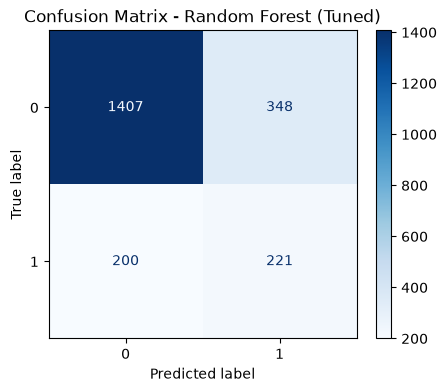


==================== تقرير التقييم التفصيلي لـ [Gradient Boosting (Tuned)] ====================
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1755
           1       0.35      0.66      0.46       421

    accuracy                           0.70      2176
   macro avg       0.62      0.68      0.62      2176
weighted avg       0.79      0.70      0.73      2176



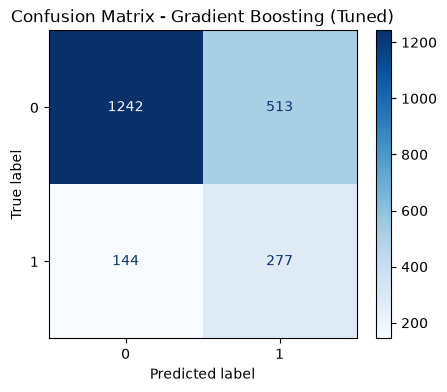

In [22]:
import matplotlib.pyplot as plt  # استيراد مكتبة الرسم البياني
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)  # استيراد أدوات عرض مصفوفة الارتباك وتقرير التصنيف
folder_name = os.path.join('..', 'reports')

# 1. التكرار على النموذجين المحسنين لعرض تقارير الأداء ومصفوفة الارتباك
for name, model in tuned_models.items():  # حلقة تكرارية تمر على اسم النموذج وكائنه المحسن
    y_pred = model.predict(
        X_test_scaled
    )  # التنبؤ بالفئات على بيانات الاختبار المقيسة

    print(
        f"\n==================== تقرير التقييم التفصيلي لـ [{name}] ===================="
    )  # طباعة عنوان لكل نموذج
    print(
        classification_report(y_test, y_pred)
    )  # طباعة تقرير التصنيف الشامل (Precision, Recall, F1) لكل فئة

    # رسم مصفوفة الارتباك Confusion Matrix
    fig, ax = plt.subplots(
        figsize=(5, 4)
    )  # تحديد قياسات الشكل البياني للمصفوفة
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap="Blues"
    )  # رسم مصفوفة الارتباك بألوان زرقاء
    plt.title(
        f"Confusion Matrix - {name}"
    )  # وضع عنوان الرسم البياني باسم الخوارزمية
    # 💾 حفظ الصورة بدقة عالية داخل المجلد قبل العرض
    plt.savefig(os.path.join(folder_name, f'ConfusionMatrix_{name}.png'), dpi=300, bbox_inches='tight')
    plt.show()  # إظهار الرسم البياني على الشاشة

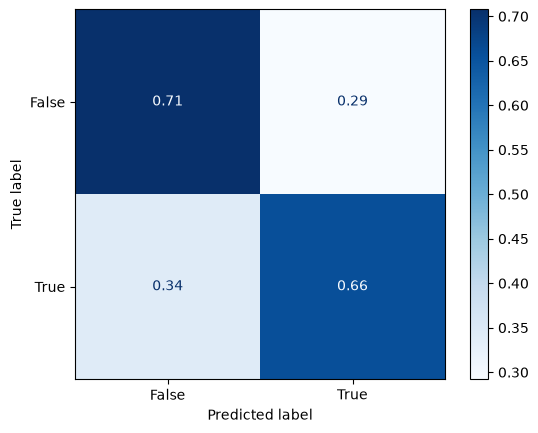

              precision    recall  f1-score   support

       False       0.90      0.71      0.79      1755
        True       0.35      0.66      0.46       421

    accuracy                           0.70      2176
   macro avg       0.62      0.68      0.62      2176
weighted avg       0.79      0.70      0.73      2176



In [23]:
# استدعاء دالة حساب مصفوفة الارتباك ودالة التقرير الشامل من مكتبة sklearn
from sklearn.metrics import classification_report, confusion_matrix

# استدعاء أداة رسم مصفوفة الارتباك بصرياً
from sklearn.metrics import ConfusionMatrixDisplay

# استدعاء مكتبة الرسم البياني
import matplotlib.pyplot as plt

folder_name = os.path.join('..', 'reports')

# حساب المصفوفة مع استخدام normalize='true' لحساب النسب المئوية بالنسبة لكل فئة حقيقية
cm = confusion_matrix(y_test, y_pred, normalize='true')

# إعداد شكل مصفوفة الارتباك وتحديد أسماء الفئات لتظهر بشكل واضح
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False', 'True'])

# رسم المصفوفة باستخدام التدرج الأزرق لتمثيل النسب المئوية بصرياً
disp.plot(cmap=plt.cm.Blues)

# عرض الرسم البياني للمصفوفة على الشاشة
plt.savefig(os.path.join(folder_name, f'ConfusionMatrix_TF.png'), dpi=300, bbox_inches='tight')

plt.show()

# طباعة التقرير الشامل الذي يعرض Precision و Recall و F1-score بشكل مستقل لكل فئة
print(classification_report(y_test, y_pred, target_names=['False', 'True']))

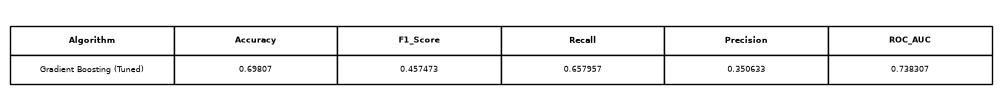

تم حفظ مخطط Gradient Boosting (Tuned) بنجاح 


In [24]:
# 1. استيراد مكتبة os لإدارة المسارات والمجلدات في النظام
import os

# 2. استيراد مكتبة Pandas للتعامل مع البيانات والجدولة
import pandas as pd

# 3. استيراد مكتبة Matplotlib لرسم وتصدير الجدول كصورة
import matplotlib.pyplot as plt

# 4. تحديد نتائج خوارزمية Gradient Boosting (Tuned) فقط في قاموس مستقل دون أي خوارزميات أخرى
gb_results = {
    'Algorithm': ['Gradient Boosting (Tuned)'],
    'Accuracy': [0.698070],       
    'F1_Score': [0.457473],
    'Recall': [0.657957],
    'Precision': [0.350633],
    'ROC_AUC': [0.738307]
}

# 5. تحويل نتائج الخوارزمية إلى إطار بيانات DataFrame من صف واحد فقط
df_gb = pd.DataFrame(gb_results)

# 6. تحديد المسار بالرجوع خطوة للأعلى من مجلد notebooks والدخول لمجلد reports
reports_dir = os.path.join('..', 'reports')

# 7. إنشاء مجلد reports تلقائياً في حال عدم وجوده مسبقاً
os.makedirs(reports_dir, exist_ok=True)

# 8. تحديد الاسم والمسار النهائي لصورة المخطط
save_path = os.path.join(reports_dir, 'gb_tuned_metrics.png')

# 9. إنشاء الشكل البياني بمقاس مخصص لصف واحد فقط
fig, ax = plt.subplots(figsize=(10, 1.2))

# 10. إخفاء المحاور البيانية بالكامل لإظهار الجدول بشكل مستقل
ax.axis('off')

# 11. تعيين خلفية إطار الشكل الخارجي باللون الأبيض
fig.patch.set_facecolor('white')

# 12. بناء الجدول بإدراج قيم وقيم عناوين خوارزمية Gradient Boosting فقط
table = ax.table(
    cellText=df_gb.values,
    colLabels=df_gb.columns,
    cellLoc='center',
    loc='center'
)

# 13. تكبير أبعاد الخلايا لتناسب النص
table.scale(1.1, 1.8)

# 14. تعيين حجم الخط داخل خلايا الجدول
table.set_fontsize(10)

# 15. التكرار على خلايا الجدول لتنسيق الألوان بالأسود والأبيض فقط
for (row, col), cell in table.get_celld().items():
    # 16. تعيين حدود الخلايا باللون الأسود
    cell.set_edgecolor('black')
    
    # 17. تعيين خلفية الخلايا باللون الأبيض
    cell.set_facecolor('white')
    
    # 18. تعيين لون النص داخل الخلايا باللون الأسود
    cell.get_text().set_color('black')
    
    # 19. جعل خط الصف الأول (العناوين) عريضاً (Bold)
    if row == 0:
        cell.get_text().set_weight('bold')

# 20. ضبط حواف الشكل البياني وتفادي قص الجوانب
plt.tight_layout()

# 21. حفظ الصورة بدقة عالية (300 DPI) بخلفية بيضاء داخل مجلد reports
plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')

# 22. عرض المخطط داخل دفتر الملاحظات (Notebook)
plt.show()

# 23. طباعة رسالة تأكيد الحفظ والمسار النهائي
print(f"تم حفظ مخطط Gradient Boosting (Tuned) بنجاح ")

In [25]:
import os # استيراد مكتبة نظام التشغيل للتعامل مع مسارات الملفات والمجلدات
import joblib # استيراد مكتبة joblib المخصصة لحفظ واسترجاع كائنات وهياكل تعلم الآلة

# تحديد مسار مجلد الحفظ بالرجوع خطوة للخلف مجلد واحد ثم الدخول لمجلد model
folder_name = os.path.join('..', 'model')

# التأكد من وجود مجلد model في الجذر الرئيسي للمشروع؛ وفي حال عدم وجوده يتم إنشاؤه تلقائياً
os.makedirs(folder_name, exist_ok=True)

# دمج مسار المجلد مع اسم الملف لإنشاء مسار حفظ نهائي متوافق مع كافة أنظمة التشغيل
file_path = os.path.join(folder_name, 'gradient_boosting_model.pkl')

# حفظ كائن النموذج المدرب في المسار المحدد داخل مجلد model
joblib.dump(model, file_path)

print("تم حفظ النموذج المعتمد بنجاح!")

تم حفظ النموذج المعتمد بنجاح!
